In [2]:
from typing import Optional
from ollama import chat # type: ignore
from pydantic import BaseModel, Field # type: ignore
import json
import pandas as pd
import glob

from collections import defaultdict

# from itertools import product
import unicodedata
from unidecode import unidecode

import tiktoken
import re


# Perform chunking on manuscript.txt

In [3]:
import argparse
import json
import os
import re

def split_text_into_windows(corpus, window_size=500, overlap=250, document_name="doc"):
    results = []
    step_size = window_size - overlap

    for start_idx in range(0, len(corpus), step_size):
        end_idx = min(start_idx + window_size, len(corpus))

        extracted_text = corpus[start_idx:end_idx]

        results.append({
            "extracted_text": extracted_text,
            "start_idx": start_idx,
            "end_idx": end_idx,
            "index_type": "character",
            "document_name": document_name
        })

        if end_idx == len(corpus):
            break

    return results

def tokenize_with_offsets(text, encoding="cl100k_base"):
    """Tokenizes text and returns tokens with their character start positions."""
    enc = tiktoken.get_encoding(encoding)
    tokens = []

    etks = enc.encode(text)
    dtks, ptks = enc.decode_with_offsets(etks)

    assert len(etks) == len(ptks)

    for t, p in zip(etks, ptks):
        token = enc.decode_single_token_bytes(t).decode("utf-8")
        tobj = {
            "token": token,
            "enc_token": t,
            "start_idx": p,
            "end_idx": p + len(token),
        }
        tokens.append(tobj)
    return tokens

import tiktoken

def split_text_into_windows(corpus, window_size=200, overlap=50, document_name="doc", encoding="cl100k_base"):
    tokens = tokenize_with_offsets(corpus, encoding=encoding)
    results = []

    step_size = window_size - overlap
    for start_idx in range(0, len(tokens), step_size):
        end_idx = min(start_idx + window_size, len(tokens))

        window_tokens = tokens[start_idx:end_idx]

        extracted_text = corpus[window_tokens[0]['start_idx']:window_tokens[-1]['end_idx']]

        results.append({
            "extracted_text": extracted_text,
            "start_idx": window_tokens[0]['start_idx'],
            "end_idx": window_tokens[-1]['end_idx'],
            "index_type": "character",
            "document_name": document_name
        })

        if end_idx == len(tokens):
            break

    return results


In [4]:
ds_name = "adipose_Emont2022"
paper_fn = f"/Users/sinabooeshaghi/projects/llmarkers/data/{ds_name}/manuscript/manuscript.txt"

with open(paper_fn, "r") as f:
    paper = f.read().strip()

# Split the text into windows
windows = split_text_into_windows(paper, window_size=100, overlap=10, document_name=f"{ds_name}")

In [5]:
windows[0]

{'extracted_text': 'Main \n \nAn atlas of human white adipose tissue \n \nMature adipocytes are too large and fragile to withstand traditional single-cell approaches. As a result, several groups have focused on the non-adipocyte stromal-vascular fraction (SVF) of mouse^(3,4,5,6) and human7 adipose tissue. An alternative strategy involves single-nucleus sequencing (sNuc-seq), which can capture adipocytes, and has been used to describe mouse white^(',
 'start_idx': 0,
 'end_idx': 427,
 'index_type': 'character',
 'document_name': 'adipose_Emont2022'}

In [6]:
windows[1]

{'extracted_text': ', and has been used to describe mouse white^(8,9) and human brown adipose tissue10. To compare these approaches in the context of human white adipose tissue (WAT), we pursued experiments on two cohorts of subjects. In the first, we collected subcutaneous WAT from nine women, isolated single cells from the SVF using collagenase digestion, and then performed whole-cell Drop-seq (hereafter referred to as single-cell RNA sequencing (scRNA-seq)). Because',
 'start_idx': 382,
 'end_idx': 835,
 'index_type': 'character',
 'document_name': 'adipose_Emont2022'}

In [7]:
len(windows)

173

In [8]:
idx = 54
paper[windows[idx]["start_idx"]:windows[idx]["end_idx"]] == windows[idx]["extracted_text"]

True

# Run LLM check on each chunk

## Marker Gene Extraction

In [9]:
from pydantic import BaseModel, Field
from typing import List, Optional

# Permissive class object (allows for missing fields)
class GeneFinder(BaseModel):
    hasCelltypeGene: bool = Field(False, description="Does the text discuss biological cell type marker genes?")

In [10]:
def extract_genes(user_content, system_prompt, data_model, model="llama3.2"):
    response = chat(
        messages=[
            {
                'role': 'system',
                'content': system_prompt,
            },
            {
                'role': 'user',
                'content': user_content,
            }
        ],
        model = model,
        format = data_model.model_json_schema(),
        options={'temperature': 0},  # Make responses more deterministic

    )
    genes = data_model.model_validate_json(response.message.content)
    return genes.model_dump()

system_prompt = """
You are an expert biologist specialized in identifying discussions about cell types and their associated marker genes in scientific texts. Your job is to determine if the provided text discusses relationships between cell types and their marker genes. The text may contain scientific jargon, abbreviations, and complex sentences. Your task is to identify whether the text discusses cell types and their marker genes.

Does the following text discuss relationships between cell types and their marker genes?

Criteria for “True”:
- Mentions or implies cell types AND specifically mentions a gene or set of genes.
- Discusses marker genes as identifying, characterizing, or differentiating particular cell types.

Otherwise, return “False”.
"""

In [11]:
check = []
for idx, window in enumerate(windows[:10]):

    genes = extract_genes(window["extracted_text"], system_prompt, GeneFinder, model="llama3.2")
    if idx % 50 == 0:
        print(f"Processed {idx} rows.")
    window.update({"hasCelltypeGene": genes["hasCelltypeGene"]})
    check.append(window)

Processed 0 rows.


In [13]:
check[0]

{'extracted_text': 'Main \n \nAn atlas of human white adipose tissue \n \nMature adipocytes are too large and fragile to withstand traditional single-cell approaches. As a result, several groups have focused on the non-adipocyte stromal-vascular fraction (SVF) of mouse^(3,4,5,6) and human7 adipose tissue. An alternative strategy involves single-nucleus sequencing (sNuc-seq), which can capture adipocytes, and has been used to describe mouse white^(',
 'start_idx': 0,
 'end_idx': 427,
 'index_type': 'character',
 'document_name': 'adipose_Emont2022',
 'hasCelltypeGene': False}

# Filter chunks

In [94]:
filt = [i for i in check if i["hasCelltypeGene"]]

In [95]:
len(filt)

86

# Merge adjacent chunks

In [96]:
merged = []

current = filt[0]

for next_row in filt[1:]:
    if current['end_idx'] > next_row['start_idx']:
        # Calculate the non-overlapping part
        overlap_len = current['end_idx'] - next_row['start_idx']
        current['extracted_text'] += next_row['extracted_text'][overlap_len:]
        current['end_idx'] = next_row['end_idx']
    else:
        merged.append(current)
        current = next_row.copy()

merged.append(current)

# Verify position of chunks

In [97]:
print(len(merged) == sum([
    paper[m['start_idx']:m['end_idx']] == m['extracted_text'] for m in merged
]))

True


In [98]:
len(merged)

21

In [99]:
merged[2]

{'extracted_text': ' of adipocytes and ASPCs did not differ between depots, but depot clearly affects the distribution of cells within these populations (Extended Data Fig. 1a, b, Extended Data Table 2, Supplementary Fig. 1). In our limited cohort, we could not detect major effects of body mass index (BMI) on cell-type proportions. To assess this finding at larger scale, we used our dataset as a reference to estimate cell-type proportions in bulk RNA-sequencing data12 obtained from',
 'start_idx': 1987,
 'end_idx': 2453,
 'index_type': 'character',
 'document_name': 'adipose_Emont2022',
 'hasCelltypeGene': True}

In [100]:
def reformat_merged(merged):
    reformatted = []
    for m in merged:
        reformatted.append({
            "extracted": {
                "organism": "",
                "cell_type_label": "",
                "cell_source": "",
                "cell_state": "",
                "feature_name": "",
                "feature_type": "",
            },
            "derived": {
                "organism": "",
                "cell_type_id": "",
                "cell_type_label": "",
                "cell_source": "",
                "cell_state": "",
                "feature_name": "",
                "feature_type": "",
                "feature_identifier": "",
                "feature_identifier_type": "",
            },
            "source": {
                "source_rationale": m["extracted_text"],
                "source_type": "text",
                "source_id": "text"
            }
        })
    return reformatted
reformatted = reformat_merged(merged)

# Compare chunk position

In [101]:
import unicodedata
import re
from unidecode import unidecode

def norm_text(text):
    if not isinstance(text, str):
        try:
            text = str(text)
        except:
            return ""

    text = unicodedata.normalize("NFC", text)
    text = unidecode(text)

    char_map = {
        "–": "-", "—": "--", "‘": "'", "’": "'", "“": '"', "”": '"', "…": "...",
        "•": "*", "·": ".", "×": "x", "÷": "/", "≤": "<=", "≥": ">=", "≠": "!=",
        "≈": "~", "∞": "inf", "∂": "d", "∫": "integral", "∑": "sum", "∏": "product",
        "√": "sqrt", "∝": "prop to", "∠": "angle", "△": "triangle", "□": "square",
        "∈": "in", "∉": "not in", "⊂": "subset", "⊃": "superset", "∪": "union",
        "∩": "intersect", "⊆": "subseteq", "⊇": "superseteq",
    }

    for char, replacement in char_map.items():
        text = text.replace(char, replacement)

    text = text.replace("\n", " ")
    text = re.sub(r"\s+", " ", text)

    return text

In [102]:
manuscript_fn = "/Users/sinabooeshaghi/projects/llmarkers/data/adipose_Emont2022/manuscript/manuscript.txt"
with open(manuscript_fn, "r") as f:
    manuscript = f.read()

In [103]:
fn = "/Users/sinabooeshaghi/projects/llmarkers/data/adipose_Emont2022/evidence_human/evidence.json"
ds_name = fn.split("/")[-3]
df = pd.read_json(fn)
df = df['source'].apply(pd.Series)
df["source_rationale"]  = df["source_rationale"].apply(lambda x: norm_text(x))

tdf = df.query("source_type == 'text'").copy()

In [107]:
tdf["found_source_rationale"] = tdf["source_rationale"].map(lambda x: x in manuscript)

In [108]:
good = tdf.query("found_source_rationale")

In [109]:
good[["start_idx", "stop_idx"]] = good.source_rationale.map(
    lambda x: (manuscript.find(x), manuscript.find(x) + len(x) if manuscript.find(x) != -1 else -1)
).tolist()

In [110]:
good

,source_type,source_rationale,source_id,found_source_rationale,start_idx,stop_idx
0,text,We identified six distinct subpopulations of h...,text,True,9783,9993
1,text,"For example, mASPC2 and hASPC2 are characteriz...",text,True,10187,10430
2,text,"Similarly, mASPC4 and hASPC4 express Epha3 and...",text,True,10431,10621
3,text,"Thus, the adipokines adiponectin and adipsin (...",text,True,16292,16388
4,text,genes encoding insulin signalling components s...,text,True,16393,16499
5,text,genes encoding insulin signalling components s...,text,True,16393,16499
6,text,genes encoding insulin signalling components s...,text,True,16393,16499
7,text,hAd3 was associated with 'triglyceride biosynt...,text,True,17104,17215
8,text,hAd3 was associated with 'triglyceride biosynt...,text,True,17104,17215
9,text,hAd3 was associated with 'triglyceride biosynt...,text,True,17104,17215


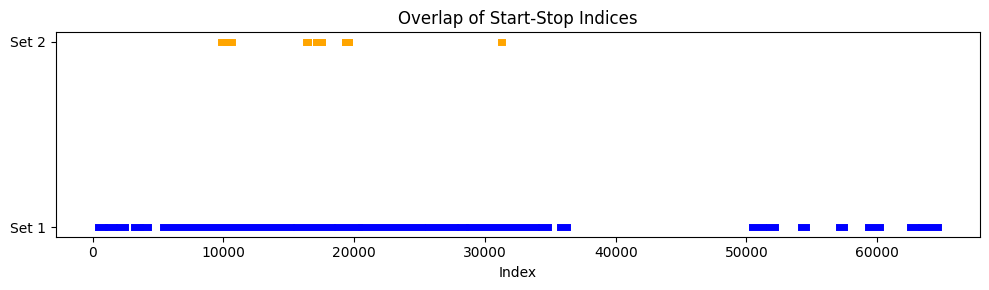

In [111]:
import matplotlib.pyplot as plt

# Example data (replace with your own indices)
set1 = [(1, 5), (7, 10), (12, 15)]
set2 = [(3, 6), (9, 13), (14, 17)]

fig, ax = plt.subplots(figsize=(10, 3))

# Plot set1
for o in merged:
    start = o['start_idx']
    stop = o['end_idx']
    ax.plot([start, stop], [1, 1], color='blue', linewidth=5, label='Set 1' if start == set1[0][0] else "")

# Plot set2
for _, row in good.iterrows():
    start = row['start_idx']
    stop = row['stop_idx']
    ax.plot([start, stop], [2, 2], color='orange', linewidth=5, label='Set 2' if start == set2[0][0] else "")

ax.set_yticks([1, 2])
ax.set_yticklabels(['Set 1', 'Set 2'])
ax.set_xlabel('Index')
ax.set_title('Overlap of Start-Stop Indices')

plt.tight_layout()
plt.show()


In [112]:
merged[-1]

{'extracted_text': ' count data were split into files containing cells from the inguinal and perigonadal fat of chow- and HFD-fed mice. Mouse gene names were converted to human gene names, as above, before running CellphoneDB with statistical analysis on each file. \n \nIdentification of candidate aetiologic cell types using CELLEX and CELLECT \n \nCELLECT and CELLEX were used to identify candidate aetiological cell types for a total of 23 traits. The input data for CELLECT is GWAS summary statistics for a given trait and cell type expression specificity (ES) estimates derived from single-cell RNA-seq data. The output is a list of prioritized candidate aetiologic cell types for a given trait. ES estimates were calculated using CELLEX (version 1.1), which computes robust estimates of ES by relying on multiple expression specificity measures (for further details see Timshel et al.44). CELLEX was run separately on the raw mouse and human (sNuc) gene expression matricies to compute gene ex